<a href="https://colab.research.google.com/github/priyanshusinha07/Cafe-project/blob/main/major_project_4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("PhishingData.csv")

In [4]:
print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (11055, 32)
   index   having_IPhaving_IP_Address   URLURL_Length   Shortining_Service   \
0       1                           -1               1                    1   
1       2                            1               1                    1   
2       3                            1               0                    1   
3       4                            1               0                    1   
4       5                            1               0                   -1   

   having_At_Symbol   double_slash_redirecting   Prefix_Suffix   \
0                  1                         -1              -1   
1                  1                          1              -1   
2                  1                          1              -1   
3                  1                          1              -1   
4                  1                          1              -1   

   having_Sub_Domain   SSLfinal_State   Domain_registeration_length   ...  \
0                 

DATA PREPROCESSING

In [5]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Convert labels if needed (Example: -1 -> 0)
y = y.replace(-1, 0)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (8844, 31)
Testing Size: (2211, 31)


FEATURE SCALLING

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
gb_model = GradientBoostingClassifier(random_state=42)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Training model with GridSearch...")
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Training model with GridSearch...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}



Model Accuracy: 0.968340117593849

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       980
           1       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



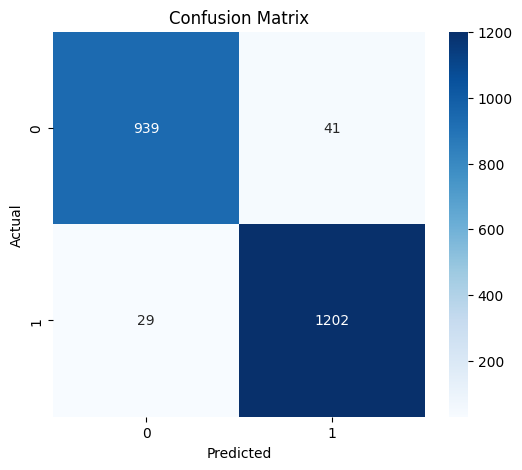

In [9]:
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
cv_score = cross_val_score(best_model, X_train_scaled, y_train, cv=5)
print("\nCross Validation Accuracy:", cv_score.mean())



Cross Validation Accuracy: 0.9637047287497857


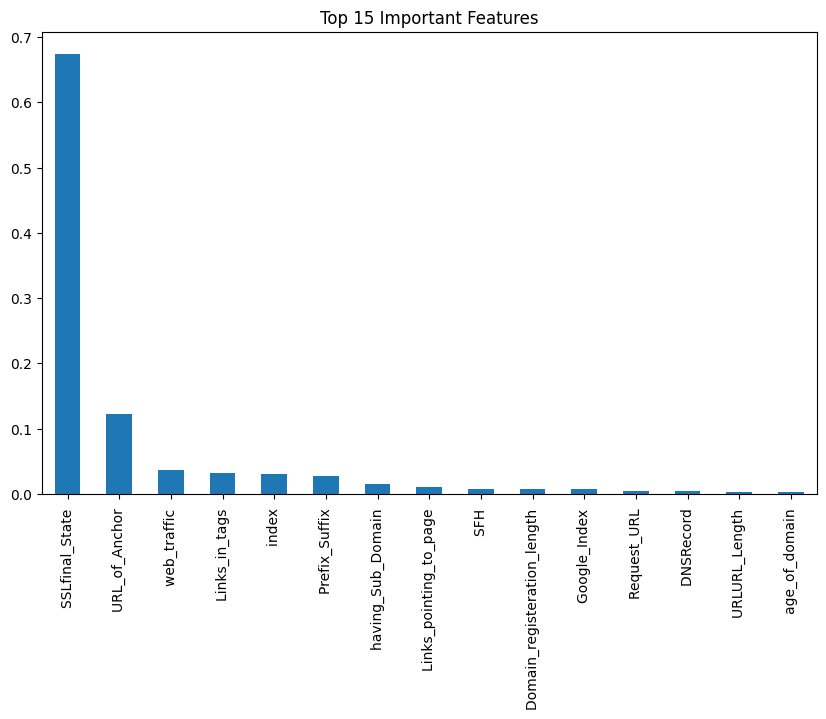

In [11]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [12]:
joblib.dump(best_model, "gradient_boosting_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and Scaler saved successfully!")



Model and Scaler saved successfully!


In [13]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


Deep Learning


In [15]:
df = pd.read_csv("PhishingData.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (11055, 32)
   index   having_IPhaving_IP_Address   URLURL_Length   Shortining_Service   \
0       1                           -1               1                    1   
1       2                            1               1                    1   
2       3                            1               0                    1   
3       4                            1               0                    1   
4       5                            1               0                   -1   

   having_At_Symbol   double_slash_redirecting   Prefix_Suffix   \
0                  1                         -1              -1   
1                  1                          1              -1   
2                  1                          1              -1   
3                  1                          1              -1   
4                  1                          1              -1   

   having_Sub_Domain   SSLfinal_State   Domain_registeration_length   ...  \
0                 

In [16]:

# Remove unnecessary column
df = df.drop(columns=["index "])

# Rename target column
df.rename(columns={"Result": "target"}, inplace=True)

# Convert -1 to 0 (for binary classification)
df["target"] = df["target"].replace(-1, 0)

print(df["target"].value_counts())

target
1    6157
0    4898
Name: count, dtype: int64


Feature

In [17]:
X = df.drop("target", axis=1)
y = df["target"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Feature scaleing


In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Deep leaning model


In [20]:
model = Sequential()

# Input Layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#Model compile

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8584 - loss: 0.3173 - val_accuracy: 0.9376 - val_loss: 0.1436
Epoch 2/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9415 - loss: 0.1444 - val_accuracy: 0.9448 - val_loss: 0.1223
Epoch 3/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9447 - loss: 0.1276 - val_accuracy: 0.9552 - val_loss: 0.1071
Epoch 4/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9557 - loss: 0.1026 - val_accuracy: 0.9616 - val_loss: 0.1016
Epoch 5/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9549 - loss: 0.1036 - val_accuracy: 0.9679 - val_loss: 0.0840
Epoch 6/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9619 - loss: 0.0842 - val_accuracy: 0.9670 - val_loss: 0.0806
Epoch 7/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9691 - loss: 0.0746 - val_accuracy: 0.9625 - val_loss: 0.0935
Epoch 8/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9674 - loss: 0.0790 - val_accu

model evaluation

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9791 - loss: 0.0552

Test Accuracy: 0.974219799041748


In [26]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
#accuracy score

In [28]:
acc = accuracy_score(y_test, y_pred)

print("\nFinal Accuracy:", acc)



Final Accuracy: 0.9742198100407056


In [29]:
#Classification Report

In [30]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       980
           1       0.97      0.99      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [31]:
#confuse matrix

In [32]:

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix\n", cm)


Confusion Matrix
 [[ 941   39]
 [  18 1213]]


In [ ]:
#accuracy graph

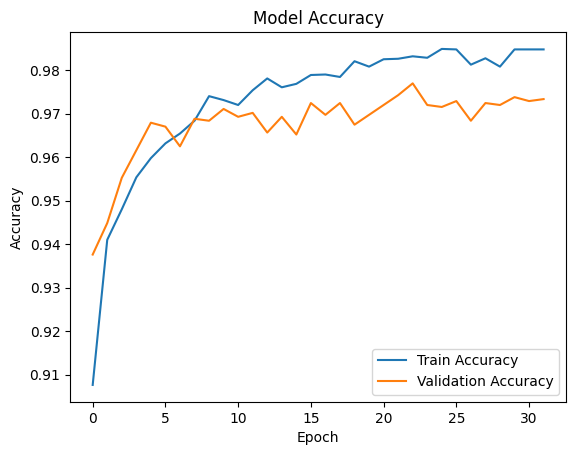

In [33]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.show()



In [34]:
#loss graph

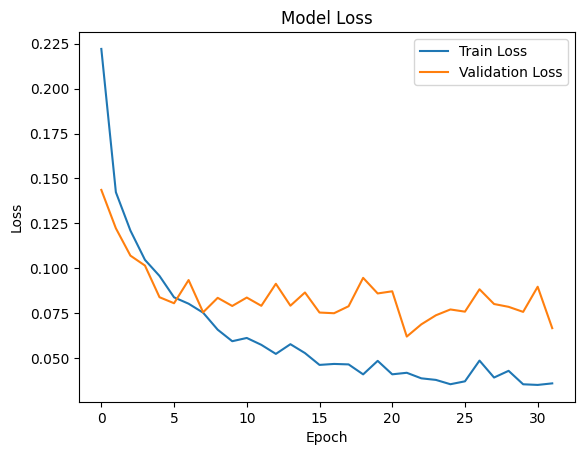

In [35]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss", "Validation Loss"])

plt.show()


In [36]:

model.save("phishing_deep_learning_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!
